# Phase 1: Exploratory Data Analysis

This notebook covers the first phase of ConstructIQ, a multi-phase AI system for construction safety risk prediction and auditing. The goal here is to explore the underlying OSHA datasets, understand what they can and cannot support, and produce a clean, construction-filtered, severity-labeled dataset that later modeling phases will build on.

## Data sources

Four files from the OSHA Enforcement Data archive (ICPSR/DataLumos, originally sourced from the U.S. Department of Labor) are used:

- `osha_accident.csv` - base accident records (date, short description, keywords)
- `osha_accident_injury.csv` - injury-level detail, including injury severity
- `osha_accident_abstract.csv` - free-text narrative describing each accident
- `osha_violation.csv` - OSHA citation and violation records, 11.9 million rows

## A note on the data

This dataset does not include a NAICS industry code. That meant construction-related records had to be identified indirectly: through keyword matching on accident descriptions for the accident files, and through the `standard` field's "1926" prefix (OSHA's construction-specific regulation series) for the violation file. Both approaches are reasonable proxies, but they are not as precise as a direct industry classification would be, and that's worth keeping in mind when interpreting the results below.

The accident-level data is also small: 774 base records. That's enough to explore patterns and train simple baseline models, but not enough on its own for the deep learning components planned for later phases. The violation dataset, filtered to construction standards, is much larger (around 3 million rows) and will likely serve as a complementary data source as the project develops.


## 1. Data dictionary

The OSHA data dictionary documents every field used across the four source files, including the meaning of coded values (for example, what `degree_of_inj = 1` represents). It's referenced throughout this notebook rather than reproduced in full.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
SRC_DIR = ROOT / "src"

sys.path.append(str(SRC_DIR))

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Raw data dir:", DATA_RAW)


Project root: C:\Users\sabin\constructiq
Raw data dir: C:\Users\sabin\constructiq\data\raw


## 2. Loading the accident tables

Three files together form one logical accident-level dataset, joined through a shared `summary_nr` identifier: the base accident record, the injury-level detail (which includes the severity label used later), and the free-text narrative, which is split across multiple rows per accident.

In [2]:
data_dict = pd.read_csv(DATA_RAW / "osha_data_dictionary.csv")
pd.set_option("display.max_colwidth", 100)
data_dict[data_dict["Table_Name"].str.contains("accident", case=False)]


,Table_Name,Column_Name,Attribute_Name,Definition,Column_Datatype,Display_Name
0,osha_accident,nonbuild_ht,Non Building Height,Construction - height in feet when not a building,"Numeric, Length=4",Height for Non-Building
1,osha_accident,project_type,Project Type,Construction - project type (code table PTYP),"Alphanumeric, Length:1",Project Type
2,osha_accident,event_date,Event Date,Date of accident (yyyymmdd),"Numeric, Length=8",Event Date
3,osha_accident,event_keyword,Event Keyword,Contains comma separated keywords entered by ERG during the review process.,"Alphanumeric, Length:200",Event Keyword
4,osha_accident,report_id,Report ID,Identifies the OSHA federal or state reporting jurisdiction,"Numeric, Length=7",Reporting ID
5,osha_accident,event_desc,Event Description,Short description of event,"Alphanumeric, Length:60",Event Description
6,osha_accident,load_dt,Load Date Timestamp,The date the load was completed.,date,No Label
7,osha_accident,summary_nr,Summary NR,Identifies the accident OSHA-170 form,"Numeric, Length=9",Summary NR
8,osha_accident,fatality,Fatality,X=Fatality is associated with accident,"Alphanumeric, Length:1",Fatality
9,osha_accident,build_stories,Stories in Building,Construction - nr of stories in building,"Numeric, Length=4",Stories in Building


## 3. Building a single narrative per accident

The abstract file stores each accident's narrative as several short lines, ordered by `line_nr`. These are concatenated into one text field per accident, which will support text-based features in later phases.

In [3]:
df_accident = pd.read_csv(DATA_RAW / "osha_accident.csv", low_memory=False)
df_injury = pd.read_csv(DATA_RAW / "osha_accident_injury.csv", low_memory=False)
df_abstract = pd.read_csv(DATA_RAW / "osha_accident_abstract.csv", low_memory=False)

print(f"osha_accident: {df_accident.shape}")
print(f"osha_accident_injury: {df_injury.shape}")
print(f"osha_accident_abstract: {df_abstract.shape}")


osha_accident: (774, 16)
osha_accident_injury: (908, 21)
osha_accident_abstract: (6186, 4)


## 4. Joining the accident tables

The join is performed at the injury level, since one accident can involve more than one injured person, and the severity label lives in the injury table.

In [4]:
df_abstract_sorted = df_abstract.sort_values(["summary_nr", "line_nr"])

narratives = (
    df_abstract_sorted
    .groupby("summary_nr")["abstract_text"]
    .apply(lambda lines: " ".join(str(l).strip() for l in lines))
    .reset_index()
    .rename(columns={"abstract_text": "full_narrative"})
)

print(f"Narratives built for {len(narratives):,} accidents")
narratives.head(3)


Narratives built for 774 accidents


,summary_nr,full_narrative
0,220010763,"On April 4, 2011, an employee was cutting up a track from a piece of heavy equipment with a torc..."
1,220010961,"At 2:00 p.m. on April 21, 2011, Employee #1 was was helping the owner move a prefabricated shed ..."
2,220011167,"At 11 a.m. on May 10, 2011, an employee was in the process of refilling the tank with abrasive w..."


## 5. Filtering to construction-related accidents

As noted above, there is no industry classification field in this dataset, so construction-related accidents are identified through keyword matching on the accident description and keyword fields. This keyword list is a reasonable starting point and could be refined further by reviewing the narratives it catches.

In [5]:
df_joined = df_accident.merge(df_injury, on="summary_nr", how="left", suffixes=("", "_injury"))
df_joined = df_joined.merge(narratives, on="summary_nr", how="left")

print(f"Joined dataset shape: {df_joined.shape}")
print(f"Unique accidents (summary_nr): {df_joined['summary_nr'].nunique()}")
df_joined.head(3)


Joined dataset shape: (908, 37)
Unique accidents (summary_nr): 774


,summary_nr,report_id,event_date,event_time,event_desc,event_keyword,const_end_use,build_stories,nonbuild_ht,project_cost,...,task_assigned,hazsub,const_op,const_op_cause,fat_cause,fall_distance,fall_ht,injury_line_nr,load_dt_injury,full_narrative
0,220239354,112000,2012-08-03 12:08:00,NaN,TWO EMPLOYEES HOSPITALIZED DUE TO BURN INJURIES.,"EXPLOSION,NATURAL GAS,GAS",NaN,NaN,NaN,NaN,...,2,NaN,NaN,NaN,NaN,NaN,NaN,1,2017-01-29 01:00:54.970462,"At 12:00 a.m. on August 3, 2012, Employee #1 and Employee #2 worked at a pizza restaurant. The r..."
1,220239354,112000,2012-08-03 12:08:00,NaN,TWO EMPLOYEES HOSPITALIZED DUE TO BURN INJURIES.,"EXPLOSION,NATURAL GAS,GAS",NaN,NaN,NaN,NaN,...,2,NaN,NaN,NaN,NaN,NaN,NaN,2,2017-01-29 01:00:54.970462,"At 12:00 a.m. on August 3, 2012, Employee #1 and Employee #2 worked at a pizza restaurant. The r..."
2,220106728,522500,2012-03-20 01:03:00,NaN,EMPLOYEE IS STRUCK BY FALLING TREE AND IS KILLED.,"TREE TRIMMING,STRUCK BY,FALLING OBJECT,TREE",NaN,NaN,NaN,NaN,...,2,NaN,NaN,NaN,NaN,NaN,NaN,1,2017-01-29 01:00:54.970462,"At 1:00 p.m. on March 20, 2012, an employee and two coworkers were cutting down and harvesting t..."


## 6. Severity label distribution

The injury severity scale runs from 1 (fatality) to 3 (no hospitalization required). This becomes the target variable for severity prediction in later phases. The distribution below is heavily skewed toward fatalities, which reflects OSHA's reporting requirements rather than the true rate of severe outcomes in construction generally, and this imbalance needs to be accounted for explicitly when building predictive models.

In [6]:
CONSTRUCTION_KEYWORDS = [
    "ladder", "scaffold", "scaffolding", "crane", "excavation", "roof",
    "construction", "concrete", "framing", "drywall", "rebar", "trench",
    "fall protection", "elevated work platform", "aerial lift"
]

combined_text = (
    df_joined["event_desc"].fillna("") + " " + df_joined["event_keyword"].fillna("")
).str.lower()

construction_mask = combined_text.str.contains("|".join(CONSTRUCTION_KEYWORDS), na=False)
df_construction = df_joined[construction_mask].copy()

print(f"Total joined rows: {len(df_joined):,}")
print(f"Construction-related rows: {len(df_construction):,}")
print(f"Share: {len(df_construction) / len(df_joined) * 100:.1f}%")


Total joined rows: 908
Construction-related rows: 209
Share: 23.0%


severity_label
Fatality            168
Hospitalized         37
Not Hospitalized      4
Name: count, dtype: int64


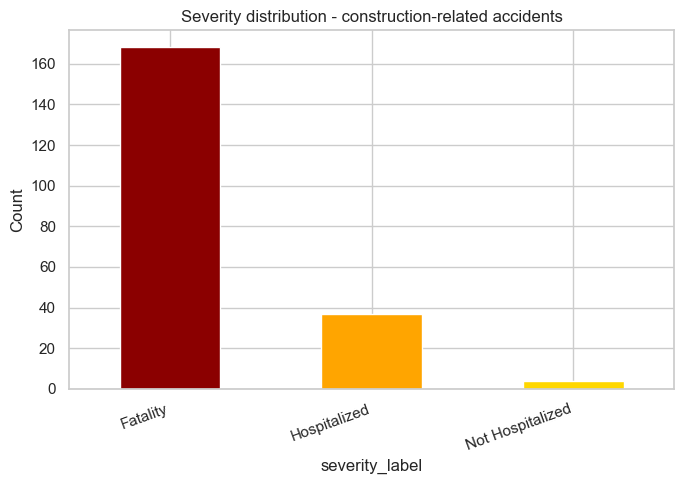

In [7]:
severity_map = {1.0: "Fatality", 2.0: "Hospitalized", 3.0: "Not Hospitalized"}
df_construction["severity_label"] = df_construction["degree_of_inj"].map(severity_map)

severity_counts = df_construction["severity_label"].value_counts(dropna=False)
print(severity_counts)

plt.figure(figsize=(7, 5))
severity_counts.plot(kind="bar", color=["darkred", "orange", "gold"])
plt.title("Severity distribution - construction-related accidents")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(MODELS_DIR / "eda_severity_distribution.png", dpi=150)
plt.show()


## 7. Accidents over time

`event_date` lets us look at trends across years and establishes the basis for a time-based train/test split in later phases. A random split would risk leaking future information into training, so any predictive model built later should split chronologically rather than randomly.


event_date_parsed
2011      7
2012    136
2015     64
2016      2
Name: count, dtype: int64


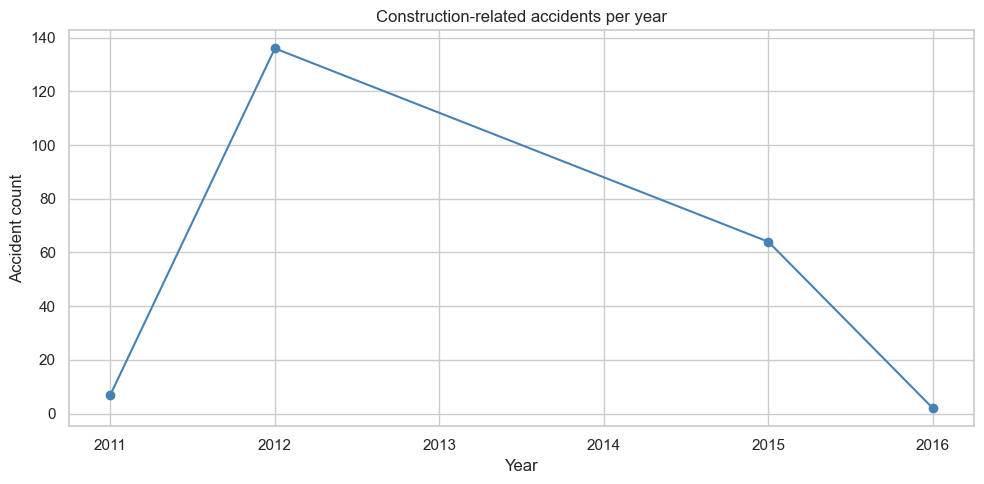


Suggested train/test cutoff year: 2016


In [8]:
df_construction["event_date_parsed"] = pd.to_datetime(df_construction["event_date"], errors="coerce")

by_year = df_construction["event_date_parsed"].dt.year.value_counts().sort_index()
print(by_year)

plt.figure(figsize=(10, 5))
by_year.plot(kind="line", marker="o", color="steelblue")
plt.title("Construction-related accidents per year")
plt.xlabel("Year")
plt.ylabel("Accident count")
plt.tight_layout()
plt.savefig(MODELS_DIR / "eda_accidents_over_time.png", dpi=150)
plt.show()

cutoff_year = by_year.index[int(len(by_year) * 0.8)] if len(by_year) > 1 else None
print(f"\nSuggested train/test cutoff year: {cutoff_year}")


## 8. Cause of injury and fatality breakdown

`fat_cause` and `const_op_cause` are coded fields (see the OSHA data dictionary for the full code tables, CAUS and OPER). These codes will be useful later for generating safety bulletins that explain why a particular risk level is elevated, rather than just reporting a score.


In [9]:
print("Fatality cause code distribution (see data dictionary for CAUS code meanings):")
print(df_construction["fat_cause"].value_counts(dropna=False).head(10))

print("\nConstruction operation cause code distribution (OPER code table):")
print(df_construction["const_op_cause"].value_counts(dropna=False).head(10))


Fatality cause code distribution (see data dictionary for CAUS code meanings):
fat_cause
NaN     116
15.0     23
20.0      9
26.0      9
16.0      8
4.0       6
14.0      5
18.0      5
3.0       5
30.0      3
Name: count, dtype: int64

Construction operation cause code distribution (OPER code table):
const_op_cause
NaN     152
70.0      9
14.0      9
43.0      4
37.0      3
11.0      2
5.0       2
12.0      2
66.0      2
71.0      2
Name: count, dtype: int64


In [10]:
for _, row in df_construction[["summary_nr", "event_desc", "full_narrative", "severity_label"]].head(5).iterrows():
    print(f"[{row['severity_label']}] {row['event_desc']}")
    print(f"  Narrative: {row['full_narrative']}")
    print()


[Hospitalized] EMPLOYEE FELL FROM LADDER AND SUSTAINED SEVERE FRACTURES AND
  Narrative: At approximately 12:40 p.m. on February 9, 2012, an employee for Wal-Mart Stores, Inc. (a local retail store) was using a 20 foot Keller Extension Ladder (Model:  3120) to access a storage retention area.  The storage retention area was approximately 130 feet" (10 ft by 10 in) above the floor and inside a caged area for the electrical breakers. It is unclear if the employee was going up the ladder or down at the time of the accident. The employee did not have any boxes in the area, only a few sheets of paper were noted on a chair in the corner of the caged area.  Some other coworkers  in the area heard a loud crash and ran to the electrical area where Employee #1 was on the floor, lying on his back and breathing as if he was snoring.  Employee #1 was hospitalized and sustained a brain injury and other fractures.

[Hospitalized] EMPLOYEE IS INJURED IN FALL FROM FIRST FLOOR WHILE FRAMING W
  Narrativ

## 9. Missing data strategy

Decisions below are based on the actual missingness observed in the data, not assumptions:

- `sex`, `fall_ht`, `fall_distance`: 100% missing across this dataset. Dropped entirely since they carry no signal.
- `hazsub`, `const_op_cause`, `fat_cause`, `const_op`: mostly missing (70-95%), but meaningful where present. Kept as categorical fields with an explicit "unknown" code (-1) rather than dropping rows, since these are only populated for certain incident types.
- `degree_of_inj`: the severity label used for modeling, missing in 6 of 908 rows. Those rows are dropped since the label can't reasonably be imputed.
- `full_narrative`: built from the abstract file, which joins to the accident table at 100% coverage, so this should be present for nearly all rows after the join.
- `event_keyword`: only 3 missing values in the base table, filled with an empty string.


In [11]:
# Drop columns that are 100% missing — carry no signal regardless of strategy
columns_to_drop = ["sex", "fall_ht", "fall_distance", "event_time", "state_flag"]
df_clean = df_construction.drop(columns=[c for c in columns_to_drop if c in df_construction.columns])

# Drop rows missing the target label — cannot train without a label, 6 rows lost
df_clean = df_clean.dropna(subset=["degree_of_inj"])

# For coded fields that are only populated for specific incident types,
# missing means "not applicable" rather than "data was lost" — fill with -1
# and add a binary missingness indicator column to preserve that information
# as a potentially predictive feature for later modeling phases
coded_fields = ["hazsub", "const_op_cause", "fat_cause", "const_op"]
for col in coded_fields:
    if col in df_clean.columns:
        df_clean[f"{col}_missing"] = (df_clean[col].isna()).astype(int)
        df_clean[col] = df_clean[col].fillna(-1)

# Fill the 3 missing event_keyword values with empty string
df_clean["event_keyword"] = df_clean["event_keyword"].fillna("")

# Confirm narrative coverage and final shape
print(f"Rows with narrative text: {df_clean['full_narrative'].notna().sum()} / {len(df_clean)}")
print(f"Missingness indicator columns added: {[c for c in df_clean.columns if c.endswith('_missing')]}")
print(f"Final cleaned shape: {df_clean.shape}")
df_clean.head()

Rows with narrative text: 209 / 209
Missingness indicator columns added: ['hazsub_missing', 'const_op_cause_missing', 'fat_cause_missing', 'const_op_missing']
Final cleaned shape: (209, 38)


,summary_nr,report_id,event_date,event_desc,event_keyword,const_end_use,build_stories,nonbuild_ht,project_cost,project_type,...,fat_cause,injury_line_nr,load_dt_injury,full_narrative,severity_label,event_date_parsed,hazsub_missing,const_op_cause_missing,fat_cause_missing,const_op_missing
3,220110720,523400,2012-02-09 12:02:00,EMPLOYEE FELL FROM LADDER AND SUSTAINED SEVERE FRACTURES AND,"FALL,LADDER",NaN,NaN,NaN,NaN,NaN,...,-1.0,1,2017-01-29 01:00:54.970462,"At approximately 12:40 p.m. on February 9, 2012, an employee for Wal-Mart Stores, Inc. (a local ...",Hospitalized,2012-02-09 12:02:00,1,1,1,1
14,220293559,523400,2012-06-08 10:06:00,EMPLOYEE IS INJURED IN FALL FROM FIRST FLOOR WHILE FRAMING W,"WORK SURFACE,FALL,FRACTURE,LEG,FALL PROTECTION,ELEVATED WORK PLATFORM,ANKLE,CONSTRUCTION",B,1.0,NaN,D,A,...,-1.0,1,2017-01-29 01:00:54.970462,"At approximately 10:00 a.m. on June 8, 2012, an employee was performing rough framing work on a ...",Hospitalized,2012-06-08 10:06:00,1,1,1,0
19,220738462,317500,2015-02-17 03:02:00,EMPLOYEE IS KILLED WHEN THROWN FROM BUCKET TRUCK WHILE TRIMM,"TREE TRIMMING,AERIAL LIFT,FALL,HEAD",NaN,NaN,NaN,NaN,NaN,...,-1.0,1,2017-01-29 01:00:54.970462,"At 3:30 p.m. on February 17, 2015, an employee was working from an elevated bucket truck while t...",Fatality,2015-02-17 03:02:00,1,1,1,1
20,220698872,419700,2015-01-04 11:01:00,EMPLOYEE DIES FROM HEAD INJURIES IN SKATEBOARDING INCIDENT,"CONCRETE SLAB,HEAD,FALL",NaN,NaN,NaN,NaN,NaN,...,-1.0,1,2017-01-29 01:00:54.970462,"At 11:15 p.m. on January 4, 2015, an employee was riding a skateboard on a public sidewalk while...",Fatality,2015-01-04 11:01:00,1,1,1,1
21,220270755,418200,2012-05-07 08:05:00,EMPLOYEE FATALLY INJURED AFTER FALLING 22 FEET FROM A FLAT R,"FALL,ROOF",C,NaN,NaN,A,B,...,15.0,1,2017-01-29 01:00:54.970462,"At approximately 8:00 am on Monday, May 7, 2012, an employee of Malon D. Mimms Company, LLC was ...",Fatality,2012-05-07 08:05:00,1,0,0,0


## 10. Save processed accident dataset

In [12]:
out_path = DATA_PROCESSED / "constructiq_accidents_construction.csv"
df_clean.to_csv(out_path, index=False)
print(f"Saved {len(df_clean):,} rows to {out_path}")


Saved 209 rows to C:\Users\sabin\constructiq\data\processed\constructiq_accidents_construction.csv


## 11. Violation file - filtering to construction (1926-series standards)

The violation file contains 11.9 million rows, far too large to load into memory at once. It's read in chunks, keeping only rows where the `standard` field starts with "1926" - OSHA's construction-specific regulation series. 

In [13]:
violation_path = DATA_RAW / "osha_violation.csv"
chunksize = 200_000
construction_chunks = []

for i, chunk in enumerate(pd.read_csv(violation_path, chunksize=chunksize, low_memory=False)):
    mask = chunk["standard"].astype(str).str.strip().str.startswith("1926")
    if mask.any():
        construction_chunks.append(chunk[mask])
    if i % 10 == 0:
        print(f"Processed {((i + 1) * chunksize):,} rows...")

df_violations_construction = pd.concat(construction_chunks, ignore_index=True)
print(f"\nTotal construction-related violations (1926-series): {len(df_violations_construction):,}")


Processed 200,000 rows...
Processed 2,200,000 rows...
Processed 4,200,000 rows...
Processed 6,200,000 rows...
Processed 8,200,000 rows...
Processed 10,200,000 rows...

Total construction-related violations (1926-series): 2,961,988


## 12. Violation severity and penalty exploration

`viol_type` (S = Serious, and other codes in the data dictionary) and `gravity` (a numeric severity score) describe how serious each violation was. `current_penalty` and `initial_penalty` capture the financial consequence, which will be useful later for an audit and compliance component of the system.


Violation type distribution:
viol_type
S      1764621
O      1091203
R        87681
W        15605
U         2854
NaN         15
F            8
H            1
Name: count, dtype: int64

Gravity score distribution:
count    1.707933e+06
mean     4.237346e+00
std      3.420187e+00
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      5.400000e+01
Name: gravity, dtype: float64


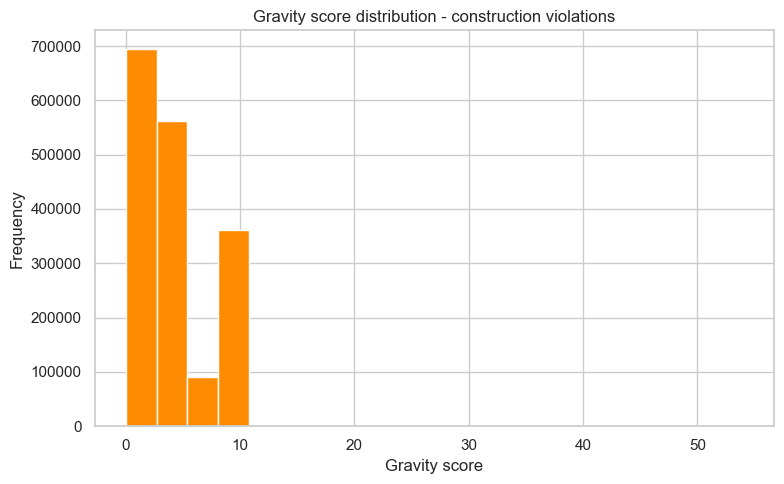

In [14]:
print("Violation type distribution:")
print(df_violations_construction["viol_type"].value_counts(dropna=False))

print("\nGravity score distribution:")
print(df_violations_construction["gravity"].describe())

plt.figure(figsize=(8, 5))
df_violations_construction["gravity"].dropna().plot(kind="hist", bins=20, color="darkorange")
plt.title("Gravity score distribution - construction violations")
plt.xlabel("Gravity score")
plt.tight_layout()
plt.savefig(MODELS_DIR / "eda_violation_gravity.png", dpi=150)
plt.show()


## 13. Most frequently cited construction standards

This identifies which specific OSHA standards (fall protection, scaffolding, and similar) are cited most often. These will help define the risk priorities for the audit component planned later in the project.


standard
19260100 A      89133
19260501 B13    67489
19260501 B01    62281
19260021 B02    54525
19260059 E01    52854
19260500 D01    43562
19260025 A      42410
19261053 B01    42004
19260652 A01    40730
19260503 A01    40458
19260404 F06    39389
19260102 A01    38576
19260059 H      36864
19260028 A      36142
19260020 B02    35350
Name: count, dtype: int64


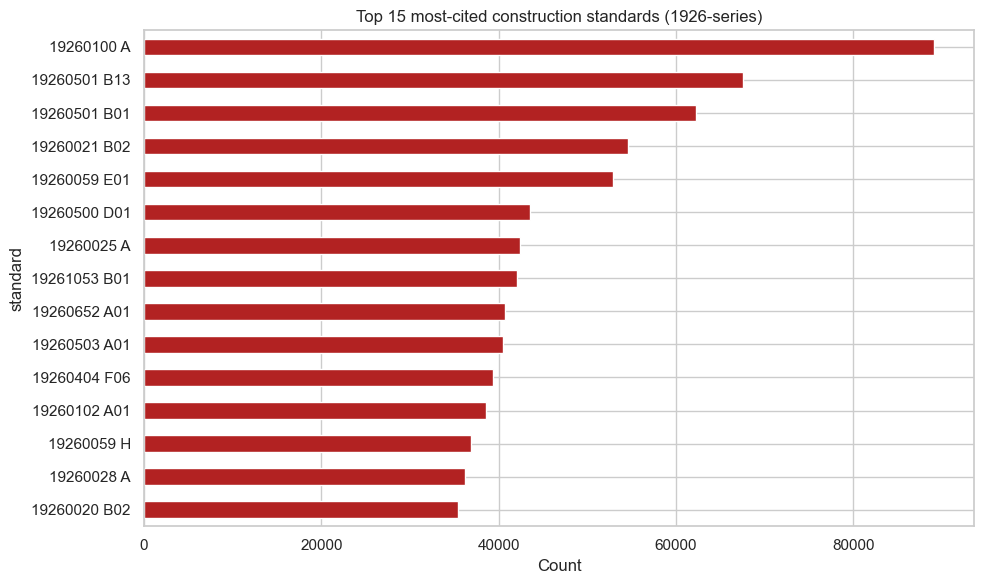

In [15]:
top_standards = df_violations_construction["standard"].value_counts().head(15)
print(top_standards)

plt.figure(figsize=(10, 6))
top_standards.plot(kind="barh", color="firebrick")
plt.title("Top 15 most-cited construction standards (1926-series)")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(MODELS_DIR / "eda_top_violation_standards.png", dpi=150)
plt.show()


## 14. Save processed violation dataset

Only the construction-filtered subset is saved here, not the full 11.9-million-row file, to keep the processed data directory a manageable size.


In [16]:
out_path_violations = DATA_PROCESSED / "constructiq_violations_construction.csv"
df_violations_construction.to_csv(out_path_violations, index=False)
print(f"Saved {len(df_violations_construction):,} rows to {out_path_violations}")


Saved 2,961,988 rows to C:\Users\sabin\constructiq\data\processed\constructiq_violations_construction.csv


## 15. Database connection check

Confirms that the PostgreSQL connection defined in `src/db.py` works, and that the schema and migration scripts have been applied correctly.


In [17]:
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import db

tables = db.test_connection()


Connected. Tables found: ['projects', 'audit_jobs', 'safety_violations', 'bulletins', 'rag_documents', 'model_results', 'raw_osha_records']


## 16. Insert the first project record

Creates a demo project record that later tables (`audit_jobs`, `bulletins`, `rag_documents`) will reference through a foreign key relationship.


In [18]:
with db.get_db() as conn:
    with conn.cursor() as cur:
        cur.execute(
            "INSERT INTO projects (name, description) VALUES (%s, %s) "
            "ON CONFLICT DO NOTHING RETURNING id;",
            ("ConstructIQ Demo Project", "Primary demo project for the ConstructIQ portfolio system")
        )
        result = cur.fetchone()
        if result:
            print(f"Inserted project with id={result[0]}")
        else:
            print("Project may already exist")

with db.get_db() as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT id, name, created_at FROM projects;")
        for row in cur.fetchall():
            print(row)


Inserted project with id=2
(1, 'ConstructIQ Demo Project', datetime.datetime(2026, 6, 17, 16, 28, 16, 716505))
(2, 'ConstructIQ Demo Project', datetime.datetime(2026, 6, 26, 11, 39, 18, 763371))


## 19. Summary

- Total accident records (raw, pre-filtering): 774
- Total injury-level records after joining accidents to injury detail: 908 (one accident can involve more than one injured person)
- Construction-related records after keyword filtering: 209, about 23% of the joined dataset
- Severity distribution among construction-related records: 168 fatalities, 37 hospitalizations, 4 non-hospitalized injuries
- Date range covered: 2011 to 2016, with the bulk of records falling in 2012 and 2015
- Construction-specific violations extracted from the violation file (1926-series standards): 2,961,988 rows, out of 11.9 million total violation records
- Most frequently cited construction standards include general scaffolding and fall protection requirements (1926.501, 1926.100) and excavation/competent person requirements (1926.21), each cited tens of thousands of times

### Limitations

A few things are worth being upfront about. The dataset has no industry classification field, so construction records were identified through keyword matching and regulation-code prefixes rather than a direct industry tag - both are reasonable proxies but introduce some noise. The accident-level dataset, after filtering, is small (209 rows), which limits how much can be learned from it alone; it's suitable for exploratory analysis and simple baseline models, but later phases will likely lean more heavily on the much larger violation dataset, possibly combined with synthetic or augmented data strategies. The severity labels are also heavily imbalanced toward fatalities, which reflects how OSHA's accident reporting requirements work (serious outcomes trigger mandatory reporting) rather than the true distribution of construction injury severity in general. This imbalance will need to be addressed explicitly in any predictive modeling, rather than ignored.

### Reproducibility

All raw data files were sourced from the OSHA Enforcement Data archive on ICPSR/DataLumos (originally published by the U.S. Department of Labor). The data dictionary included in that archive (`osha_data_dictionary.csv`) documents every coded field referenced in this notebook. Processed outputs from this notebook are saved to `data/processed/` as `constructiq_accidents_construction.csv` and `constructiq_violations_construction.csv`.

### Next steps

Phase 2 will use the processed accident dataset to train baseline statistical models (logistic regression, ridge classification, and naive bayes) predicting injury severity from accident features, establishing a performance floor that later, more complex models can be measured against.
